# Structural Estimation using DC-EGM

## Dependencies, Packages & Roots

### Magics

In [19]:
%reload_ext autoreload
%autoreload 2

### Project Paths

In [20]:
from pathlib import Path
import sys
import importlib

# Change this depending on notebook location:
# 0 = notebook is 1 folder inside project root, e.g. dp_termpaper/edu1
# 1 = notebook is 2 folders inside project root, e.g. dp_termpaper/data/moments
# 2 = notebook is 3 folders inside project root
amount_of_levels = 0

DIR = Path.cwd().resolve().parents[amount_of_levels]

if str(DIR) not in sys.path:
    sys.path.insert(0, str(DIR))

import project_paths as pp
from project_imports import *

importlib.reload(pp)
jax.config.update("jax_enable_x64", True)

### Determine Macros

In [ ]:
###############################################################
#### Define which education level you want to estimate for ####
###############################################################

education_level = "edu1"
# education_level = "edu2"
# education_level = "edu3"

# Amount of individuals in simulated sample
n_sim = 1
n_individuals = 100_000

# Whether to run the structural estimation or just load the results
structural_estimation = False

### Load Data


In [22]:

education_level_file = pp.MOMENTS_DIR / f"moments_{education_level}.txt"

MORTALITY = pp.DATA_DIR / "mortality.xlsx"

beta0, beta1, beta2 = np.loadtxt(pp.FIRST_STAGE_RESULTS_DIR / f"wage_params_{education_level}_ols.txt")
alpha1, alpha2 = np.loadtxt(pp.STRUCTURAL_RESULTS_DIR/ "mortality_params.txt")

In [23]:
# Read CSV
df_edu = pd.read_csv(education_level_file)
# read mortality and discard seoncd and third column
df_mort = pd.read_excel(MORTALITY, sheet_name="DOD", usecols=[0, 3])

# 2) standardize colomn name and remove _FREQ_ column
# Iterate over DataFrames (if there are multiple DataFrames to process)
for data_frame in [df_edu]:
    # Rename ALDER → age
    if "ALDER" in data_frame.columns:
        data_frame.rename(columns={"ALDER": "age"}, inplace=True)
    # Remove _FREQ_-column if it exists
    # if "_FREQ_" in data_frame.columns:
    #     data_frame.drop(columns=["_FREQ_"], inplace=True)
# drop var_wage, skew_wage and pens
df_edu.drop(columns=["var_wage", "skew_wage", "pens"], errors="ignore", inplace=True)
# df_edu

## Options for model - Choices and states

In [24]:
n_periods = 55
labour_choices = np.arange(5) # 5 choices

model_config = {
    "n_periods": n_periods,
    "choices": labour_choices, # 5 choices
    "n_quad_points": 5,
    "continuous_states": {
        "assets_end_of_period": np.linspace(0, 50, 20),
        "experience": jnp.linspace(0, 1, 5).astype(float) # 1 experince grid point, if experience can only go up by a year - more points if it is a fraction based on hours worked
        },
    "stochastic_states": {
        "survival": [0, 1],
    }
    }

model_specs = {
    "choices": labour_choices, # 5 choices
    "n_periods": n_periods,
    "labour_choices": labour_choices, # 5 choices
    "hours": jnp.array([0,250,750,1300,1900]), #list 
    "max_hours": 1900,
    "start_age": 30,
    "tax_threshold1": 0.480,
    "tax_threshold2": 5.698,
    "tax_base_rate": 0.38,
    "tax_top_rate": 0.5,
    "retirement_age": 67,
    "oap_base_amount": 0.80328,
    "oap_max_supplement": 0.92940,
    "supp_threshold": 0.79300,
    "oap_threshold": 3.3592,
    "supp_reduction_rate": 0.309,
    "oap_reduction_rate": 0.3,
    "alpha1": alpha1, # independently estimated parameter for survival probability
    "alpha2": alpha2,  # independently estimated parameter for survival probability
    "max_init_experience": 5,
    "max_ret_period": 45, # Age 75
    "min_ret_period": 30, # Age 60
}
stochastic_states_transitions = {
    "survival": prob_survival
}

### Setup the model

In [25]:
model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=old_utility_functions,
    utility_functions_final_period=final_period_utility,
    budget_constraint=budget_dcegm_initial,
    state_space_functions=create_state_space_function_dict(),
    stochastic_states_transitions=stochastic_states_transitions,
)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  25
Model setup complete.



### Initial values for simulating

In [26]:
seed = 132
key = jax.random.PRNGKey(0)
n = n_individuals       

# hours mapping for simulation
hours_map = {0: 0, 1: 250, 2: 750, 3: 1300, 4: 1900}

#age for simulation
start_age = model_specs["start_age"] 

# distribution of initial choices
labels = jnp.array([0, 1, 2, 3, 4], dtype=jnp.int32)
probs  = jnp.array([0.259155, 0.118310, 0.108099, 0.108451, 0.405986])  # sums to 1.0

lagged_choice = jax.random.choice(
    key,
    a       = labels,
    shape   = (n,),
    p       = probs,
    replace = True
)

# set initial states for each individual
states_initial = {
    "period": jnp.zeros(n_individuals, dtype=jnp.int32),      # Every individual starts at period 0 (age 30)
    "lagged_choice": lagged_choice,  # Every individual starts with choice 3 (work fulltime)
    "experience": jnp.full(n_individuals, 1).astype(float),  # Every individual starts with 5 years of experience
    "survival": jnp.ones(n_individuals, dtype=jnp.int32), # Every individual starts with 1 (alive)
    "assets_begin_of_period": jnp.full(n_individuals, 0.505047) # Every individual starts with 59k wealth - to be adjusted based on the actual moments
}

## Plots

### Solve, simulate and plot final model

In [27]:
params = load_params_txt(pp.STRUCTURAL_RESULTS_DIR / f"original_params_{education_level}.txt")
# If you want to see Frederiks original parameters, load optimized_params_udd1.txt instead
params["gamma"] = jnp.asarray(params["gamma"])

In [28]:
model_solved = model.solve(params)
sim = model_solved.simulate(
    states_initial=states_initial,
    seed=seed,
)

Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\dp_termpaper\4. Results\plots\simulation\original_edu2_specification\empirical_vs_simulated_grid_edu2.png


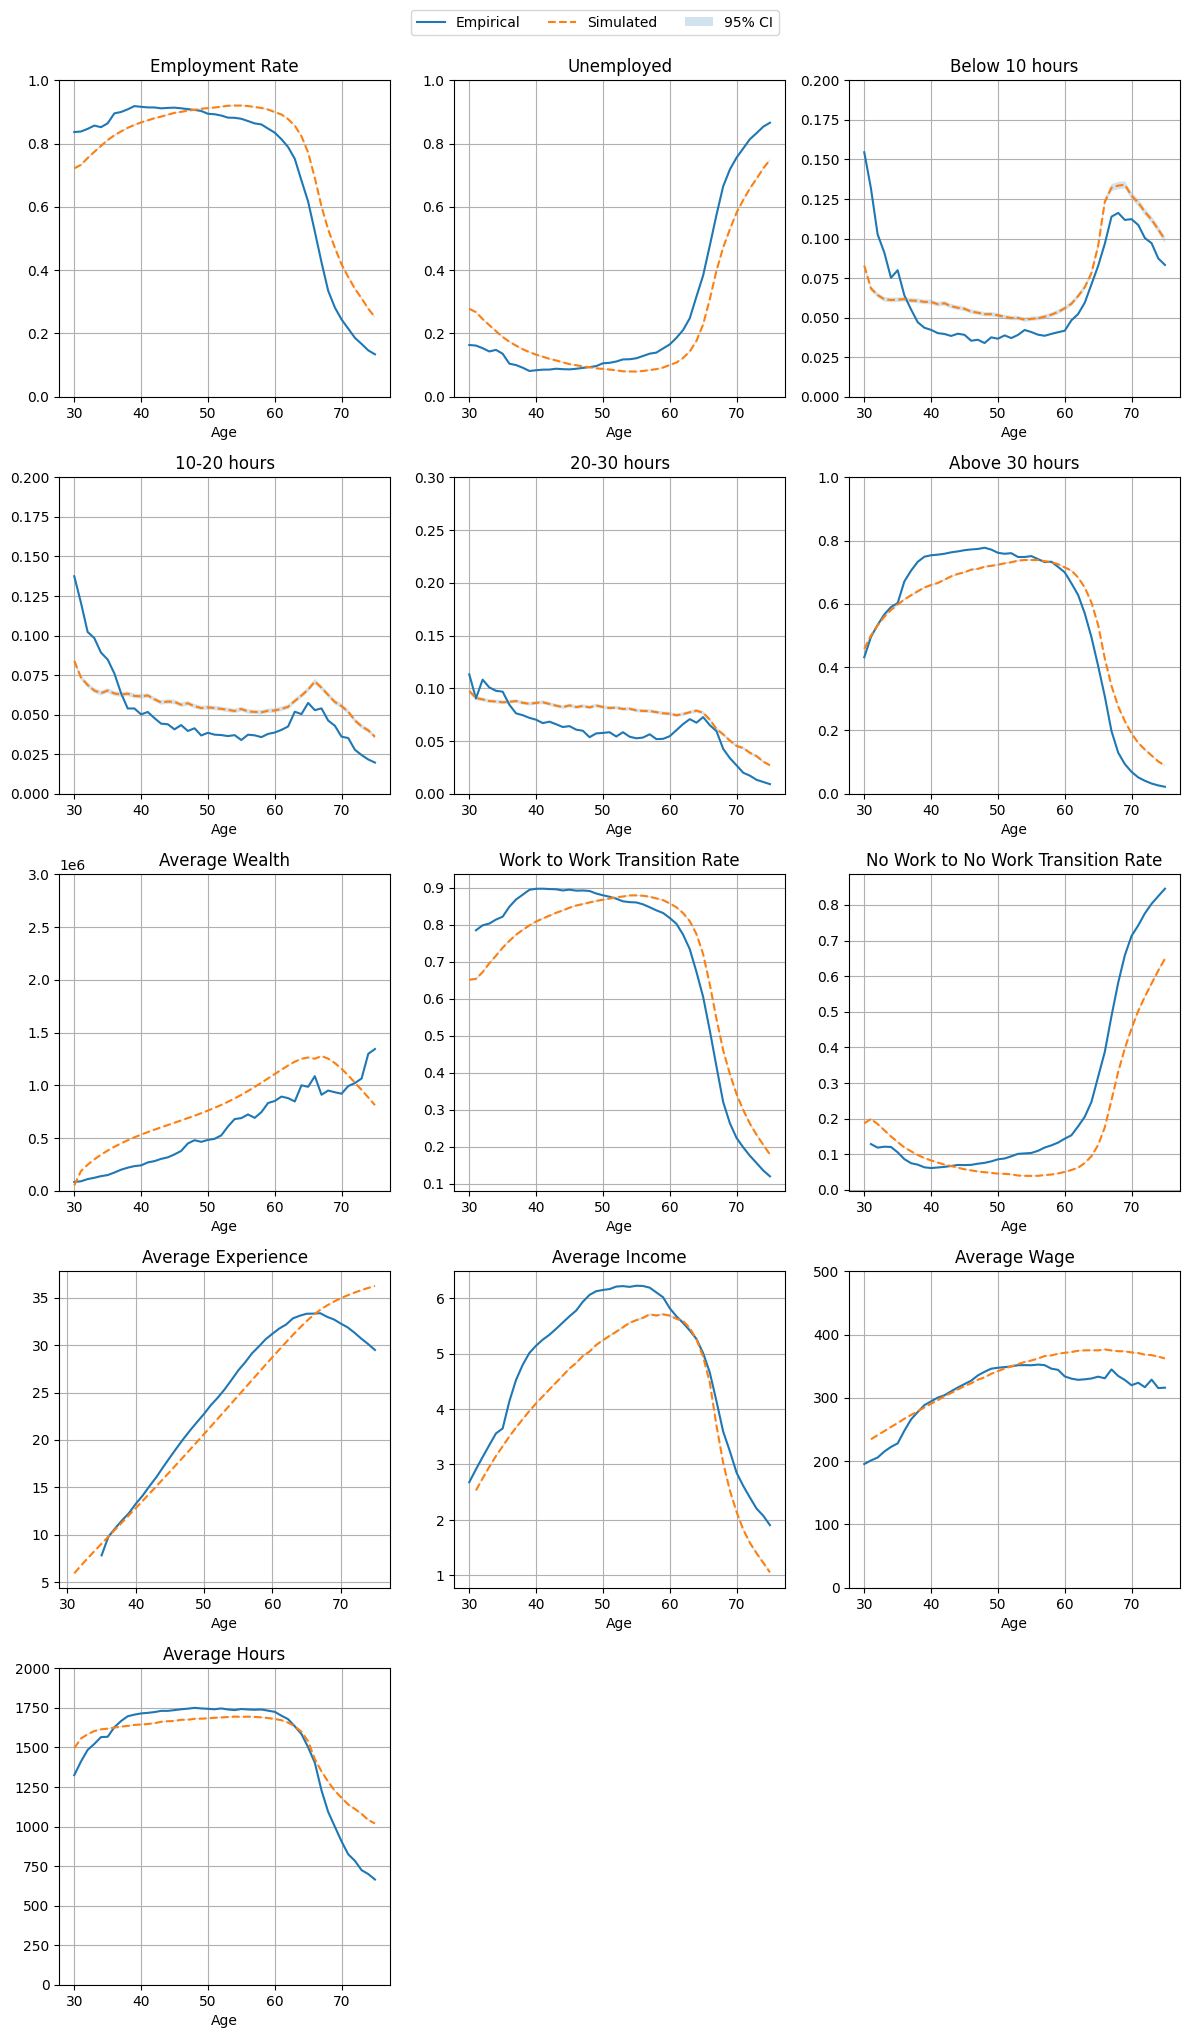

(<Figure size 1200x2000 with 13 Axes>,
 array([[<Axes: title={'center': 'Employment Rate'}, xlabel='Age'>,
         <Axes: title={'center': 'Unemployed'}, xlabel='Age'>,
         <Axes: title={'center': 'Below 10 hours'}, xlabel='Age'>],
        [<Axes: title={'center': '10-20 hours'}, xlabel='Age'>,
         <Axes: title={'center': '20-30 hours'}, xlabel='Age'>,
         <Axes: title={'center': 'Above 30 hours'}, xlabel='Age'>],
        [<Axes: title={'center': 'Average Wealth'}, xlabel='Age'>,
         <Axes: title={'center': 'Work to Work Transition Rate'}, xlabel='Age'>,
         <Axes: title={'center': 'No Work to No Work Transition Rate'}, xlabel='Age'>],
        [<Axes: title={'center': 'Average Experience'}, xlabel='Age'>,
         <Axes: title={'center': 'Average Income'}, xlabel='Age'>,
         <Axes: title={'center': 'Average Wage'}, xlabel='Age'>],
        [<Axes: title={'center': 'Average Hours'}, xlabel='Age'>,
         <Axes: >, <Axes: >]], dtype=object))

In [29]:
edu = df_edu.copy().loc[df_edu.age <= 75]       # empirical
# moments_sim = compute_simulation_moments_with_ci(sim, start_age, hours_map)  # Call the function
moments_sim = compute_simulation_moments_with_ci(sim, start_age, hours_map)  # Call the function

# Ensure moments_sim.age is a pandas Series before filtering
moments_sim = moments_sim.loc[pd.Series(moments_sim.age) <= 75]  # Filter simulated + CIs
# scale avg_wealth by 100_000

plot_empirical_vs_simulated_with_ci_grid(
    edu=edu,
    moments_sim=moments_sim,
    out_subfolder=f"original_{education_level}_specification",
    ncols=3,
    figsize_per_plot=(4, 4),
    filename=f"empirical_vs_simulated_grid_{education_level}.png",
)

Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\dp_termpaper\4. Results\plots\simulation\original_edu2_specification\prob_work_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\dp_termpaper\4. Results\plots\simulation\original_edu2_specification\hours_0_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\dp_termpaper\4. Results\plots\simulation\original_edu2_specification\hours_1_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\dp_termpaper\4. Results\plots\simulation\original_edu2_specification\hours_2_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\dp_termpaper\4. Results\plots\simulation\original_edu2_specification\hours_3_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\dp_termpaper\4. Results\plots\simulation\original_edu2_specification\hours_4_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramm

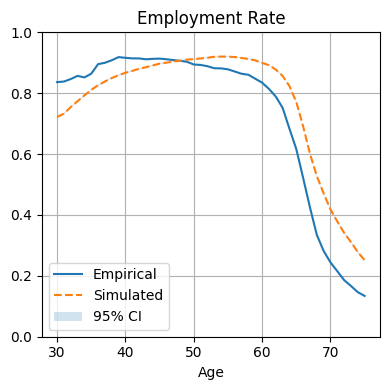

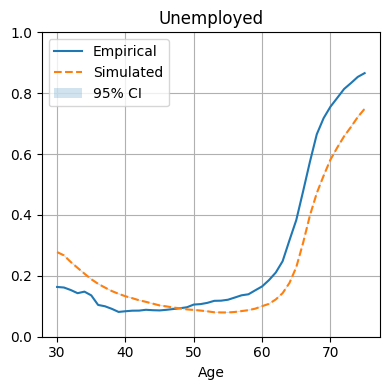

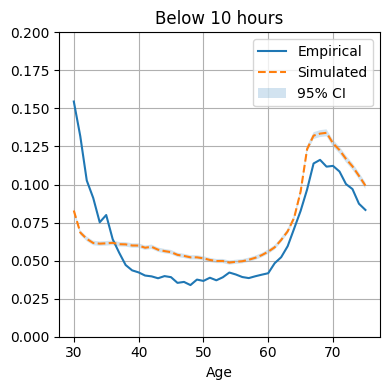

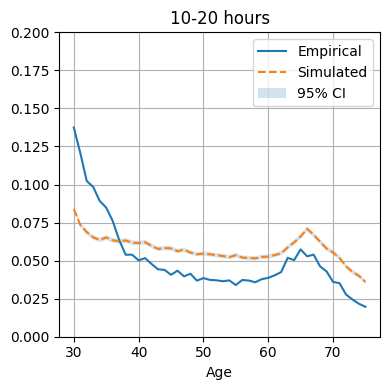

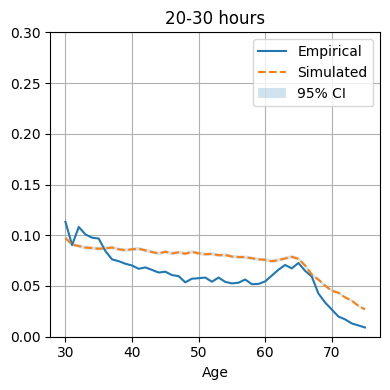

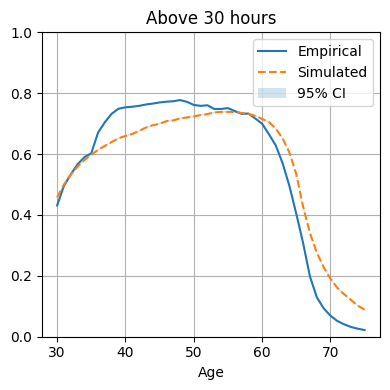

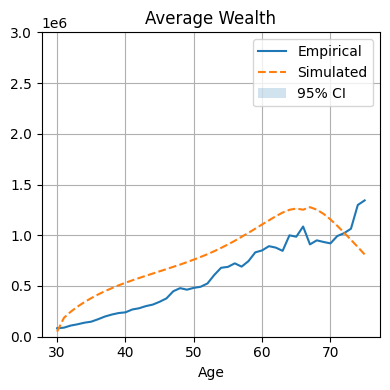

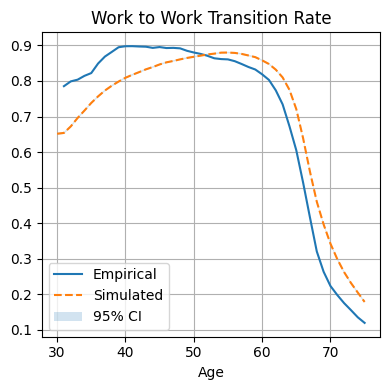

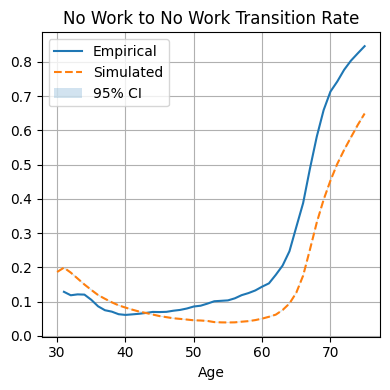

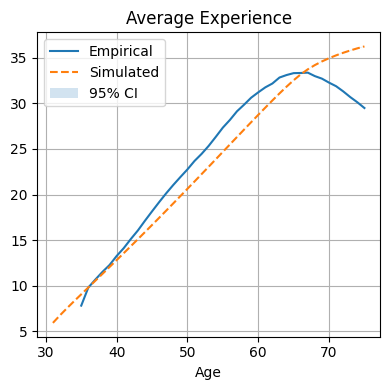

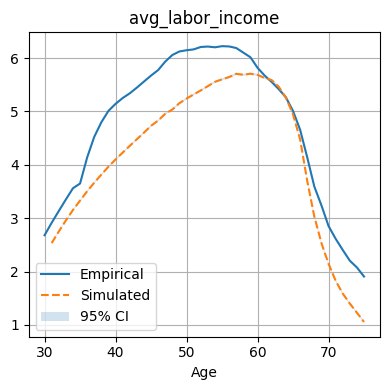

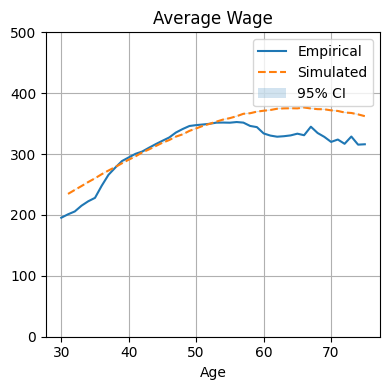

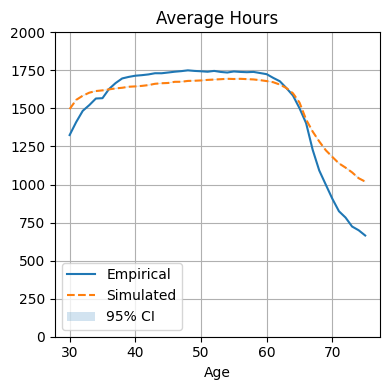

In [30]:
# print plots
plot_empirical_vs_simulated_with_ci(
    edu = edu,
    moments_sim = moments_sim,
    out_subfolder=f"original_{education_level}_specification")